# MOD510: Project 3

**Deadline: 04. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : ...

**Intro here**

## Part 1

In [ ]:
import numpy as np
import math
import numba_rk4

def func():
    '''
    dr/dt = f(r,t) , r and f are vectors
    r = (x, y, ...)
    f(r,t) = (fx(r,t), fy(r,t))
    '''
    pass

class ODESolver:
    '''
    Class docstring
    '''
    def __init__(self, f, t0, tf, h, r0, method = 'rk4', max_tol = 1e-5, adaptive = True, args = ()):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        self.n = math.ceil((tf - t0) / h)
        self.t_points = np.zeros(self.n + 2, float)
        self.r0 = np.array(r0, float)
        self.method = method
        self.choosen_method = {'euler': self.__euler,
                               'rk2': self.__rk2,
                               'rk4': self.__rk4,
                               'fast_rk4': 'numba_rk4'
                               }[method]
        self.r_points = np.zeros((self.n + 2, len(self.r0)), float)
        self.adaptive = adaptive
        self.step_exponent = {"euler":1/2, "impeuler":1/3, "rk2":1/3, "rk4":1/5, 'fast_rk4': None}[method]
        self.max_tol = max_tol
        self.args = args

    def __euler(self, t, r, h):
        '''
        Eulers method
        '''
        return h * self.f(r, t)

    def __rk2(self, t, r, h):
        '''
        Runge-Kutta second order (RK2)
        '''
        k1 = h * self.f(r, t)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h)
        return k2

    def __rk4(self, t, r, h):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        k1 = h * self.f(r, t, *self.args)
        k2 = h * self.f(r + 0.5 * k1, t + 0.5 * h, *self.args)
        k3 = h * self.f(r + 0.5 * k2, t + 0.5 * h, *self.args)
        k4 = h * self.f(r + k3, t + h, *self.args)
        return (k1 + 2 * (k2 + k3) + k4) / 6

    def solve(self):
        '''
        Doc string for solve function
        '''

        self.r_points[0] = self.r0
        self.t_points[0] = self.t0

        if self.choosen_method == 'numba_rk4':
            self.t_points, self.r_points = numba_rk4.solve(self.f, self.h, self.t0, self.tf,
                                                           self.r0, self.t_points, self.r_points,
                                                           self.adaptive, self.max_tol)
        else:
            h = self.h
            t = self.t0
            i = 0


            while t < self.tf:
                r_i = self.r_points[i]

                if self.adaptive:
                    r1 = r_i + self.choosen_method(t, r_i, h)
                    r_half = r_i + self.choosen_method(t, r_i, h/2)
                    r2 = r_half + self.choosen_method(t + h / 2, r_half, h/2)
                    Err = np.max(np.abs(r2 - r1))
                    Err = max(Err, 1e-14)
                    h = h*(self.max_tol / Err)**self.step_exponent
                h = min(h, self.tf - t)  # Do not step beyond tf/avoid overshooting
                self.r = r_i + self.choosen_method(t, r_i, h)
                self.r_points[i + 1]= self.r.copy()
                t += h
                self.t_points[i + 1]= t
                i += 1
            self.t_points = self.t_points[:i+1]
            self.r_points = self.r_points[:i+1]

        return self.t_points, self.r_points


## Part 2

In [345]:
from numba import njit

@njit
def cd_0(r, t, n = 1, tau = 2):
    """ 1 tank"""
    Cin = 0 # input concentration = 0
    return (n/tau)*(Cin - r[0])

@njit
def cd_1(r, t, n = 2, tau = 2):
    """ 2 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    return rp

@njit
def cd_2(r, t, n = 3, tau = 2):
    """ 3 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    rp[2] = (n/tau)*(r[1]- r[2])
    return rp

@njit
def c_0(t, tau = 2):
    return np.exp(-t / tau)

@njit
def c_1(t, tau = 2):
    return (2 * t / tau) * np.exp(-2 * t / tau)

@njit
def c_2(t, tau = 2):
    return 9* t**2 / (2 * tau**2) * np.exp(-3 * t / tau)

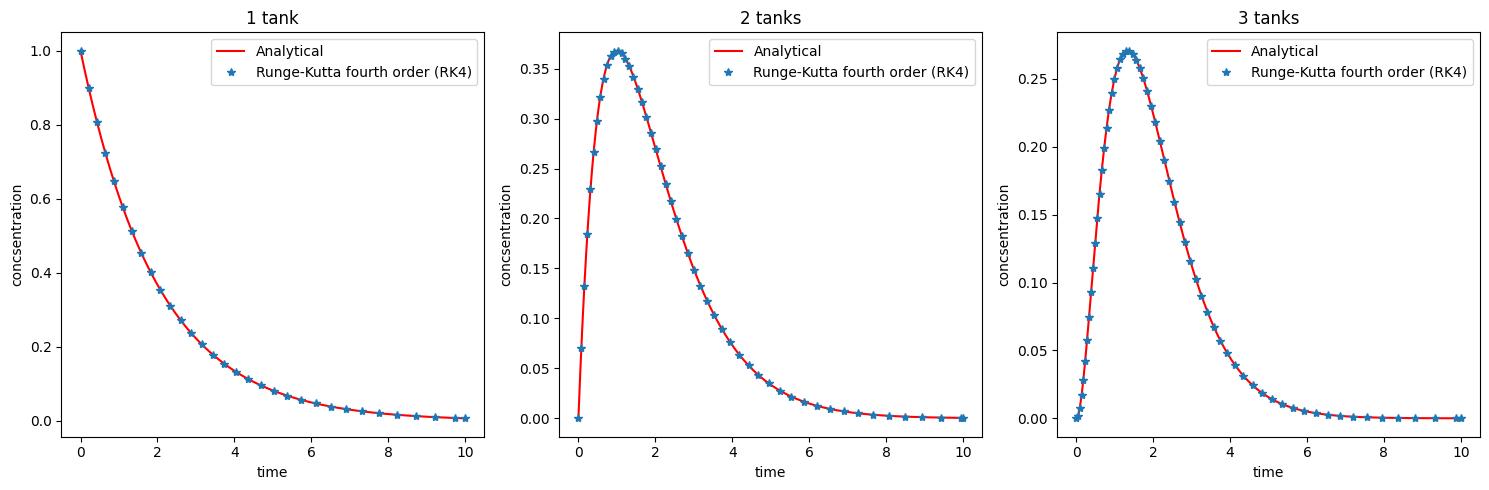

In [90]:
import matplotlib.pyplot as plt

ode_solver1 = ODESolver(cd_0, 0, 10, 1e-2, [1], 'rk4', 1e-7)
times_1, consentrations_1 = ode_solver1.solve()
ode_solver2 = ODESolver(cd_1, 0, 10, 1e-2, [1, 0], 'rk4', 1e-7)
times_2, consentrations_2 = ode_solver2.solve()
ode_solver3 = ODESolver(cd_2, 0, 10, 1e-2, [1, 0, 0], 'rk4', 1e-7)
times_3, consentrations_3 = ode_solver3.solve()

ta = np.linspace(0, 10, 1000)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(ta, c_0(ta), '-',color = 'red', label = "Analytical")
plt.plot(times_1, consentrations_1, '*',label = "Runge-Kutta fourth order (RK4)")
plt.xlabel('time')
plt.ylabel('concsentration')
plt.title('1 tank')
plt.legend()


plt.subplot(1, 3, 2)
plt.plot(ta, c_1(ta), '-', color = 'red', label = "Analytical")
plt.plot(times_2, consentrations_2[:, 1], '*',label = "Runge-Kutta fourth order (RK4)")
plt.xlabel('time')
plt.ylabel('concsentration')
plt.title('2 tanks')
plt.legend()


plt.subplot(1, 3, 3)
plt.plot(ta, c_2(ta), '-', color = 'red', label = "Analytical")
plt.plot(times_3, consentrations_3[:, 2], '*',label = "Runge-Kutta fourth order (RK4)")
plt.xlabel('time')
plt.ylabel('concsentration')
plt.title('3 tanks')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
import timeit

number = 10
cake = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'fast_rk4', 1e-7)
cake2 = ODESolver(cd_2, 0, 10, 1e-3, [1, 0, 0], 'rk4', 1e-7)

t = timeit.timeit(lambda: cake.solve(), number = number) / number
t2 = timeit.timeit(lambda: cake2.solve(), number = number) / number

print(f"With numba: {t}s")
print(f"Without numba: {t2}s")
print(f"With numba is {t2/t:.2f} times faster")

With numba: 0.00022678999994241167s
Without numba: 0.09339266999995743s
With numba is 411.80 times faster


## Part 3

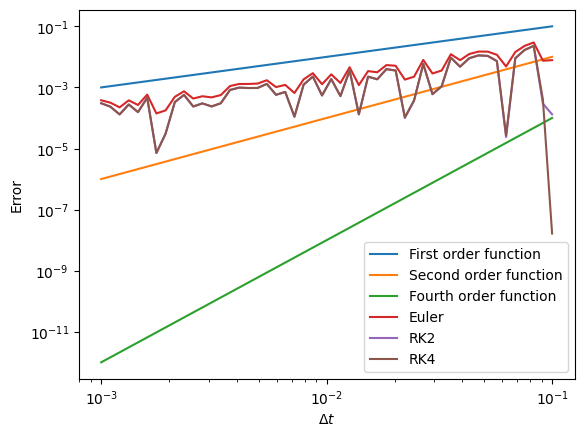

In [149]:
dts = np.logspace(-1, -3, 50)
euler_error = []
rk2_error = []
rk4_error =[]

for _, dt in enumerate(dts):
    ode_solver_euler = ODESolver(f = cd_0, t0 = 0, tf = 2, h = dt, r0 = [1], method = 'euler', adaptive = False)
    ode_solver_rk2 = ODESolver(f = cd_0, t0 = 0, tf = 2, h = dt, r0 = [1], method = 'rk2', adaptive = False)
    ode_solver_rk4 = ODESolver(f = cd_0, t0 = 0, tf = 2, h = dt, r0 = [1], method = 'fast_rk4', adaptive = False)

    times, consentrations_euler = ode_solver_euler.solve()
    _, consentrations_rk2 = ode_solver_rk2.solve()
    _, consentrations_rk4 = ode_solver_rk4.solve()

    index =  int(len(times)/2)

    euler_error.append(np.abs(c_0(t = 1) - consentrations_euler[index]))
    rk2_error.append(np.abs(c_0(t = 1) - consentrations_rk2[index]))
    rk4_error.append(np.abs(c_0(t = 1) - consentrations_rk4[index]))

plt.plot(dts, dts, label = 'First order function')
plt.plot(dts, dts**2, label = 'Second order function')
plt.plot(dts, dts**4, label = 'Fourth order function' )
plt.plot(dts, euler_error, label = 'Euler')
plt.plot(dts, rk2_error, label = 'RK2')
plt.plot(dts, rk4_error, label = 'RK4')
plt.ylabel('Error')
plt.xlabel(r'$\Delta t$')
plt.xscale('log')
plt.yscale('log')
plt.legend()


# Exercise 2: Fit CSTR model to CFD model: Healthy aorta

**Intro here**

## Part 1

$$\frac{\cancel{g}}{\frac{\cancel{g}}{mL} \cdot s} \quad \Rightarrow \quad \frac{1}{\frac{s}{mL}} \quad \Rightarrow \quad \frac{mL}{s} \quad \Rightarrow \quad \frac{\cancel{mL} \cdot \frac{1 L}{1000 \cancel{mL}}}{\cancel{s} \cdot \frac{1min}{60 \cancel{s}}} \quad \Rightarrow \quad \frac{\frac{1}{1000} L}{\frac{1}{60}min} \quad \Rightarrow \quad \frac{6}{100}\frac{L}{min}

In [664]:
import pandas as pd

c_out = pd.read_csv('Data/Healthy_rect_1s.csv', sep = ',')
c_out.head()

concentrations = np.array(c_out['Concentration']) #g/mL
times = np.array(c_out['Time'])

int_c_out = np.trapezoid(concentrations, times)

m_inj = 83.333 #g

q = m_inj / int_c_out
q = q * (6 / 100)
print(q)


5.005983664163233


## Part 2

In [706]:
def rect_1s(t):
    return np.where(t < 1, 1, 0)

def rect_2s(t):
    return np.where(t < 2, 1, 0)

def rect_3s(t):
    return np.where(t < 3, 1, 0)

def ramp_1s(t):
    return np.where(t < 1, t, 0)

def ramp_2s(t):
    return np.where(t < 2, t/2, 0)

def biphasic(t):
    y = np.zeros_like(t, dtype = float)
    y += np.where((t < 1), 0.7, 0)
    y += np.where((t > 2) & (t < 3), 1, 0)
    return y


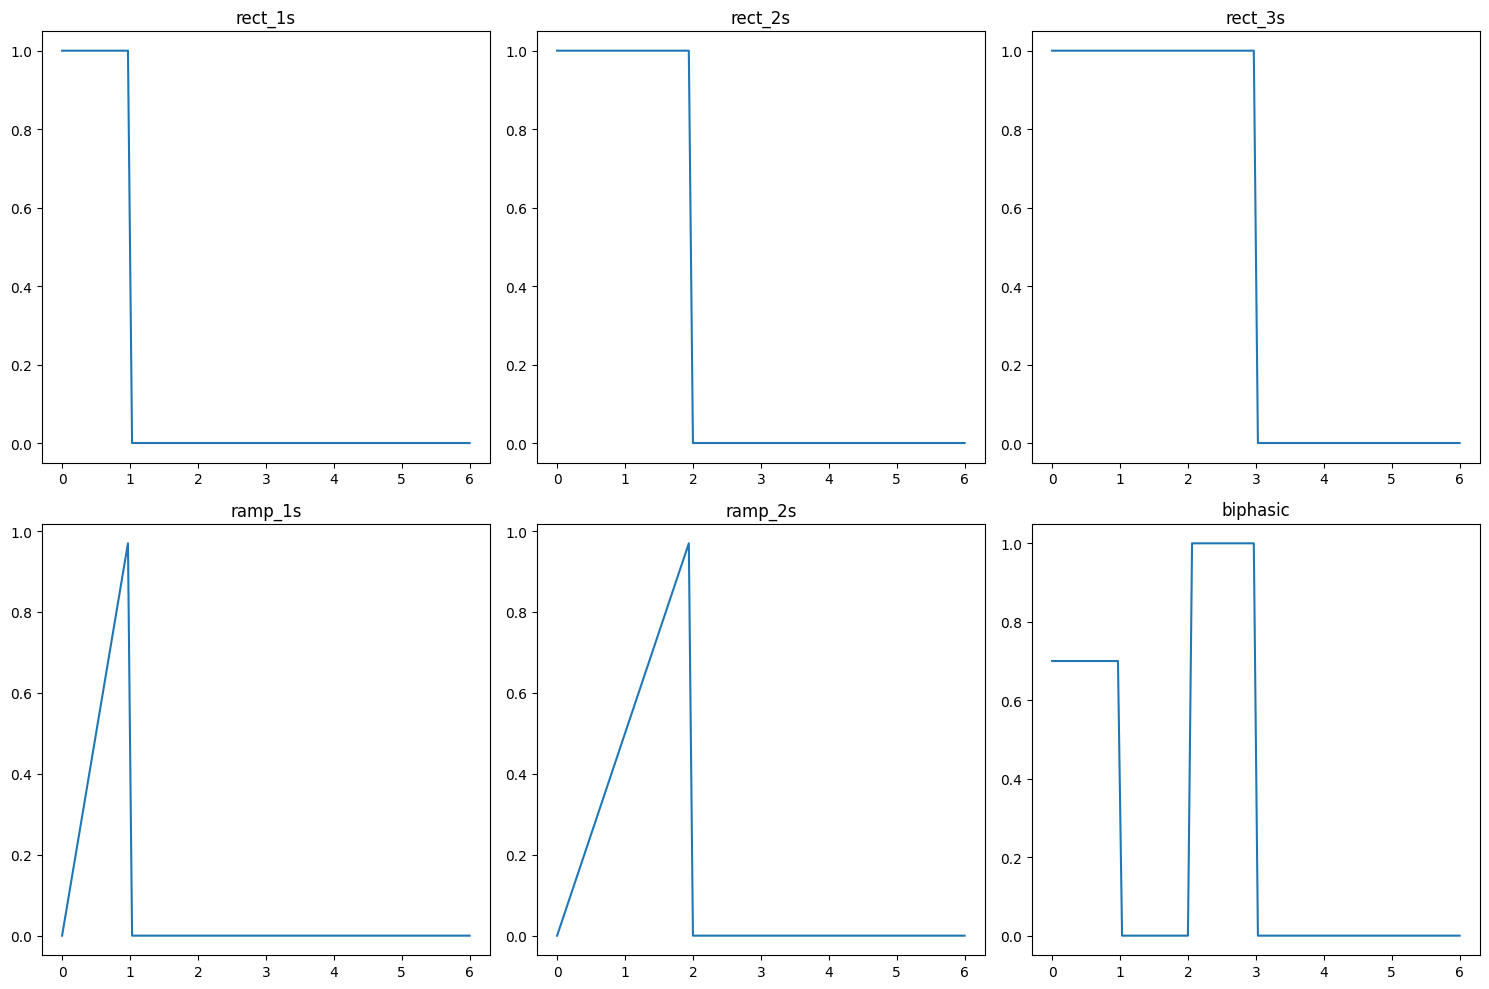

In [236]:
t = np.linspace(0, 6, 100)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(t,rect_1s(t))
plt.title('rect_1s')

plt.subplot(2, 3, 2)
plt.plot(t,rect_2s(t))
plt.title('rect_2s')

plt.subplot(2, 3, 3)
plt.plot(t,rect_3s(t))
plt.title('rect_3s')

plt.subplot(2, 3, 4)
plt.plot(t,ramp_1s(t))
plt.title('ramp_1s')

plt.subplot(2, 3, 5)
plt.plot(t,ramp_2s(t))
plt.title('ramp_2s')

plt.subplot(2, 3, 6)
plt.plot(t,biphasic(t))
plt.title('biphasic')

plt.tight_layout()
plt.show()

## Part 3

In [690]:
def cd_n(r, t, n, tau, inj_pro = rect_1s):
    c_in = inj_pro(t)
    rp = np.zeros(n)

    for i in range(n):
        if i == 0:
            rp[0] =  (n/tau) * (c_in- r[i])
        else:
            rp[i] =  (n/tau) * (r[i - 1] - r[i])
    return rp

In [691]:
n_tanks = 50
r0 = np.zeros(n_tanks)

data = pd.read_csv('Data/Healthy_rect_1s.csv')
t_data = data['Time'].to_numpy()
c_data = data['Concentration'].to_numpy()

def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
    t_model, c_model = solver.solve()
    c_out = np.interp(t_data, t_model, c_model[:, -1])
    return np.sum((c_data - c_out) ** 2)

def d_ssr(tau, delta_tau = 1e-3):
    return (ssr(tau + delta_tau) - ssr(tau)) / (2*delta_tau)


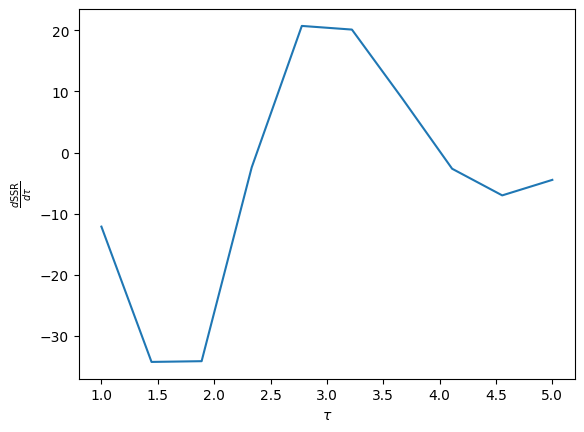

In [692]:
tau_values = np.linspace(1 , 5,10)
d_ssr_values = []

for tau in tau_values:
    d_ssr_values.append(d_ssr(tau))

plt.plot(tau_values, d_ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\frac{d \text{SSR}}{d \tau}$')
plt.show()

In [ ]:
def secant_method(f, x0, x1, h = 1e-4, prec = 1e-8, max_iter = 100):
    '''
    Finds an extremum of f(x) using the secant method
    '''
    def fd(x):
        return (f(x + h) - f(x - h)) / (2 * h)

    fd0 = fd(x0)
    for i in range(1, max_iter):
        fd1 = fd(x1)
        ratio = (x1 - x0) / (fd1 - fd0)
        x2 = x1 - fd1 * ratio

        xdiff = abs(x2 - x1)
        x0, x1 = x1, x2
        fd0 = fd1

        if abs(xdiff / x2) < prec:
            break
    else:
        x2 = None

    return x2, i

In [694]:
tau, iter = secant_method(f = ssr, x0 = 1, x1 = 3, h = 1e-4, prec = 1e-8, max_iter = 100)
print(f'Found τ = {tau:.2f} after {iter} iterations')
print(f'With τ = {tau:.2f} we get d(ssr)/dτ = {d_ssr(tau):.2f}')

Found τ = 2.37 after 7 iterations
With τ = 2.37 we get d(ssr)/dτ = 0.04


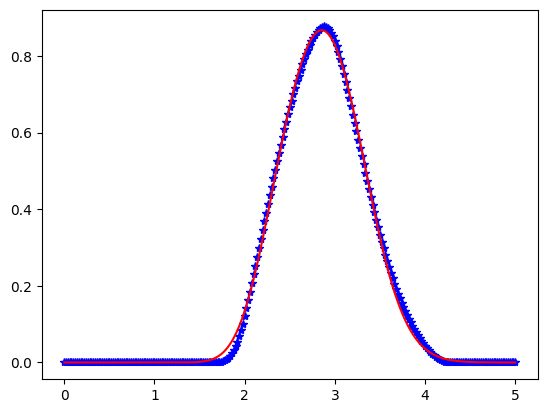

In [695]:
solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model, c_model = solver.solve()

plt.plot(t_data, c_data, '*', color = 'blue')
plt.plot(t_model, c_model[:,-1],'-', color = 'red')
plt.show()


In [ ]:
best_v_tot = tau * q *(100/6)
print(f"The 'best match' V_tot is {best_v_tot:.2f}mL with τ = {tau:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 197.41mL with τ = 2.37s and q = 5.01L/min


## Part 4

In [751]:
from functools import partial

f_rect2s = partial(cd_n, inj_pro=rect_2s)
f_rect3s = partial(cd_n, inj_pro=rect_3s)
f_ramp1s = partial(cd_n, inj_pro=ramp_1s)
f_ramp2s = partial(cd_n, inj_pro=ramp_2s)
f_biphasic = partial(cd_n, inj_pro=biphasic)

solver_re2 = ODESolver(f=f_rect2s, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_re2, c_model_re2 = solver_re2.solve()

data_re2 = pd.read_csv('Data/Healthy_rect_2s.csv')
t_data_re2 = data_re2['Time'].to_numpy()
c_data_re2 = data_re2['Concentration'].to_numpy()

solver_re3 = ODESolver(f=f_rect3s, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_re3, c_model_re3 = solver_re3.solve()

data_re3 = pd.read_csv('Data/Healthy_rect_3s.csv')
t_data_re3 = data_re3['Time'].to_numpy()
c_data_re3 = data_re3['Concentration'].to_numpy()

solver_ra1 = ODESolver(f=f_ramp1s, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_ra1, c_model_ra1 = solver_ra1.solve()

data_ra1 = pd.read_csv('Data/Healthy_ramp_1s.csv')
t_data_ra1 = data_ra1['Time'].to_numpy()
c_data_ra1 = data_ra1['Concentration'].to_numpy()

solver_ra2 = ODESolver(f=f_ramp2s, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_ra2, c_model_ra2 = solver_ra2.solve()

data_ra2 = pd.read_csv('Data/Healthy_ramp_2s.csv')
t_data_ra2 = data_ra2['Time'].to_numpy()
c_data_ra2 = data_ra2['Concentration'].to_numpy()

solver_bi = ODESolver(f=f_biphasic, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_bi, c_model_bi = solver_bi.solve()

data_bi = pd.read_csv('Data/Healthy_biphasic.csv')
t_data_bi = data_bi['Time'].to_numpy()
c_data_bi = data_bi['Concentration'].to_numpy()

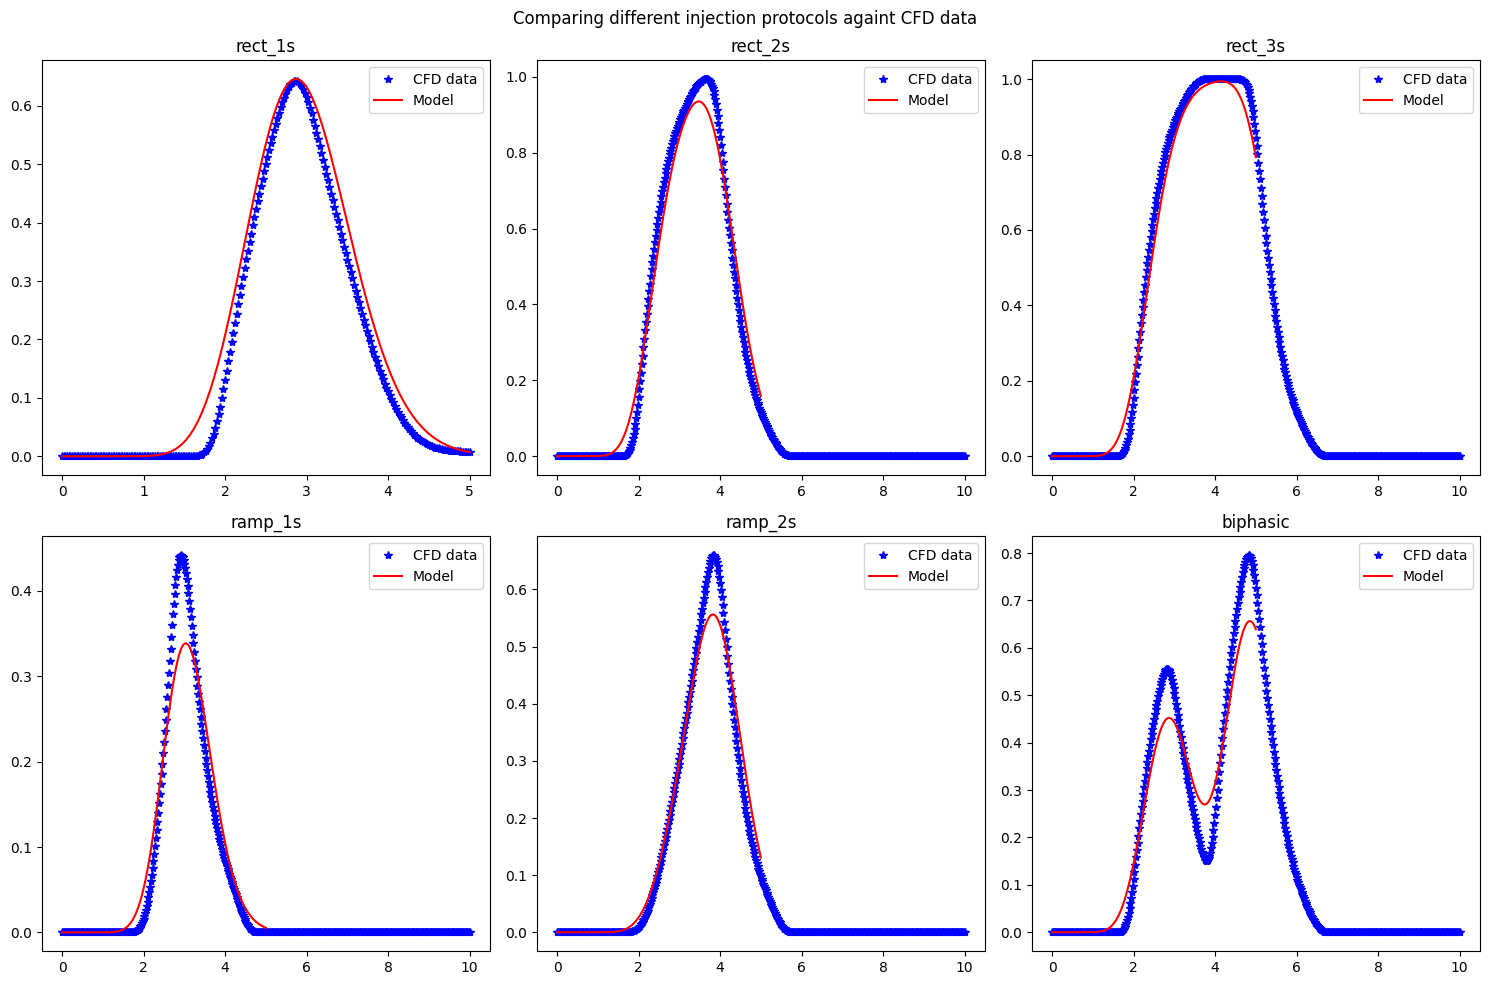

In [752]:
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(t_data, c_data, '*', color = 'blue', label = cdf_label)
plt.plot(t_model, c_model[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_1s')
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(t_data_re2, c_data_re2, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_re2, c_model_re2[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_2s')
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(t_data_re3, c_data_re3, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_re3, c_model_re3[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_3s')
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(t_data_ra1, c_data_ra1, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_ra1, c_model_ra1[:, -1],'-', color = 'red', label = model_label )
plt.title('ramp_1s')
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(t_data_ra2, c_data_ra2, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_ra2, c_model_ra2[:, -1],'-', color = 'red', label = model_label )
plt.title('ramp_2s')
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(t_data_bi, c_data_bi, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_bi, c_model_bi[:, -1],'-', color = 'red', label = model_label)
plt.title('biphasic')
plt.legend()

plt.suptitle('Comparing different injection protocols againt CFD data')
plt.tight_layout()
plt.show()

# Exercise 3: Fit CSTR model to CFD model: Aorta with aneurysm

**Intro here**

## Part 1

In [753]:
n_tanks = 20
r0 = np.zeros(n_tanks)

data = pd.read_csv('Data/Aneurysm_rect_1s.csv')
t_data = data['Time'].to_numpy()
c_data = data['Concentration'].to_numpy()

def ssr(tau):
    solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
    t_model, c_model = solver.solve()
    c_out = np.interp(t_data, t_model, c_model[:, -1])
    return np.sum((c_data - c_out) ** 2)


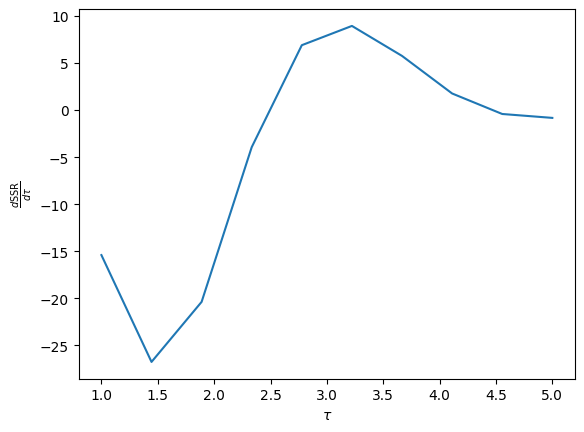

In [754]:
tau_values = np.linspace(1 , 5,10)
d_ssr_values = []

for tau in tau_values:
    d_ssr_values.append(d_ssr(tau))

plt.plot(tau_values, d_ssr_values)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\frac{d \text{SSR}}{d \tau}$')
plt.show()

In [755]:
tau, iter = secant_method(f = ssr, x0 = 1, x1 = 3, h = 1e-4, prec = 1e-8, max_iter = 100)
print(f'Found τ = {tau:.2f} after {iter} iterations')
print(f'With τ = {tau:.2f} we get d(ssr)/dτ = {d_ssr(tau):.2f}')

Found τ = 2.46 after 7 iterations
With τ = 2.46 we get d(ssr)/dτ = 0.01


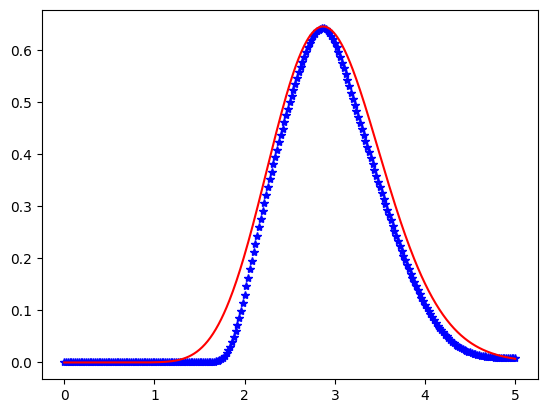

In [756]:
solver = ODESolver(f=cd_n, t0=0, tf=5, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model, c_model = solver.solve()

plt.plot(t_data, c_data, '*', color = 'blue')
plt.plot(t_model, c_model[:,-1],'-', color = 'red')
plt.show()

In [757]:
best_v_tot = tau * q *(100/6)
print(f"The 'best match' V_tot is {best_v_tot:.2f}mL with τ = {tau:.2f}s and q = {q:.2f}L/min")

The 'best match' V_tot is 205.05mL with τ = 2.46s and q = 5.01L/min


## Part 2

In [763]:
from functools import partial

f_rect2s = partial(cd_n, inj_pro=rect_2s)
f_rect3s = partial(cd_n, inj_pro=rect_3s)
f_ramp1s = partial(cd_n, inj_pro=ramp_1s)
f_ramp2s = partial(cd_n, inj_pro=ramp_2s)
f_biphasic = partial(cd_n, inj_pro=biphasic)

solver_re2 = ODESolver(f=f_rect2s, t0=0, tf=10, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_re2, c_model_re2 = solver_re2.solve()

data_re2 = pd.read_csv('Data/Aneurysm_rect_2s.csv')
t_data_re2 = data_re2['Time'].to_numpy()
c_data_re2 = data_re2['Concentration'].to_numpy()

solver_re3 = ODESolver(f=f_rect3s, t0=0, tf=10, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_re3, c_model_re3 = solver_re3.solve()

data_re3 = pd.read_csv('Data/Aneurysm_rect_3s.csv')
t_data_re3 = data_re3['Time'].to_numpy()
c_data_re3 = data_re3['Concentration'].to_numpy()

solver_ra1 = ODESolver(f=f_ramp1s, t0=0, tf=10, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_ra1, c_model_ra1 = solver_ra1.solve()

data_ra1 = pd.read_csv('Data/Aneurysm_ramp_1s.csv')
t_data_ra1 = data_ra1['Time'].to_numpy()
c_data_ra1 = data_ra1['Concentration'].to_numpy()

solver_ra2 = ODESolver(f=f_ramp2s, t0=0, tf=10, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_ra2, c_model_ra2 = solver_ra2.solve()

data_ra2 = pd.read_csv('Data/Aneurysm_ramp_2s.csv')
t_data_ra2 = data_ra2['Time'].to_numpy()
c_data_ra2 = data_ra2['Concentration'].to_numpy()

solver_bi = ODESolver(f=f_biphasic, t0=0, tf=10, h=1e-2, r0=r0,
                   method='rk4', adaptive=False, args=(n_tanks, tau))
t_model_bi, c_model_bi = solver_bi.solve()

data_bi = pd.read_csv('Data/Aneurysm_biphasic.csv')
t_data_bi = data_bi['Time'].to_numpy()
c_data_bi = data_bi['Concentration'].to_numpy()

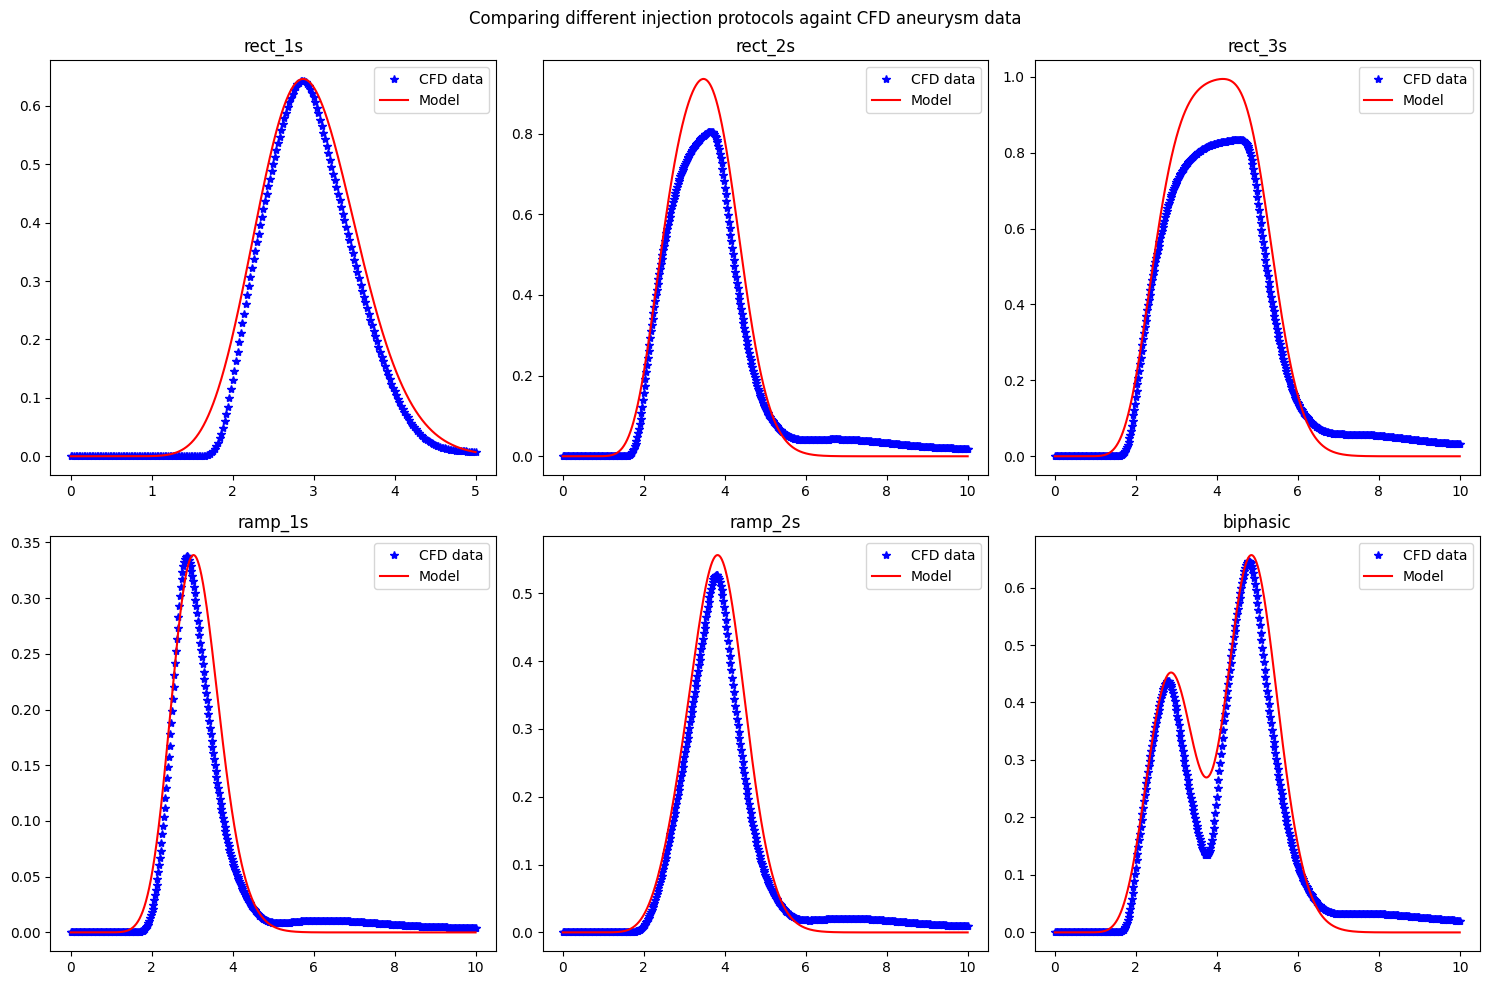

In [764]:
cdf_label = 'CFD data'
model_label = 'Model'

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(t_data, c_data, '*', color = 'blue', label = cdf_label)
plt.plot(t_model, c_model[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_1s')
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(t_data_re2, c_data_re2, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_re2, c_model_re2[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_2s')
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(t_data_re3, c_data_re3, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_re3, c_model_re3[:, -1],'-', color = 'red', label = model_label )
plt.title('rect_3s')
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(t_data_ra1, c_data_ra1, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_ra1, c_model_ra1[:, -1],'-', color = 'red', label = model_label )
plt.title('ramp_1s')
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(t_data_ra2, c_data_ra2, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_ra2, c_model_ra2[:, -1],'-', color = 'red', label = model_label )
plt.title('ramp_2s')
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(t_data_bi, c_data_bi, '*', color = 'blue', label = cdf_label)
plt.plot(t_model_bi, c_model_bi[:, -1],'-', color = 'red', label = model_label)
plt.title('biphasic')
plt.legend()

plt.suptitle('Comparing different injection protocols againt CFD aneurysm data')
plt.tight_layout()
plt.show()

## Part 3

**Reflect here**

## Part 4 

**Reflect here**

# Exercise 4: Extend model

**Intro here**

## Part 1